In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import seaborn as sns
from sklearn.metrics import silhouette_score
from mlxtend.frequent_patterns import apriori, association_rules

In [2]:
df=pd.read_excel("Online Retail.xlsx")

## Business understanding

UK-based and registered non-store online retail. <br>
The company mainly sells unique all-occasion gifts. <br>
Many customers of the company are wholesalers.

## Data understanding

#### Checks:
- Missing Values
- Format/validity check
- Not relevant data (not product data)
- Duplicates
- Consistency check
- Outliers

#### Q1: Are there any anomalies or errors in the dataset? Are there any missing values? <br>
Yes, there are several anomalies and errors. First of all, in the webpage it says that the data has no missing values, which is not correct.

##### Missing values:

- CustomerID: 135 080 missing rows (out of 541 908 rows)
- Description: 1 454 missing rows

##### Inconsistencies:

- CustomerID → Country: 8 inconsistent (all rows with the same CustomerID should reasonably have the same country)
- InvoiceNo → InvoiceDate: 43 inconsistent (all rows with the same InvoiceNo should have the same date - appears to be only time (min) that differs though)
- StockCode → Description: 650 inconsistent (should be same description/product name)

##### Duplicates:

- 5 271 exact duplicate rows after making a new df of just InvoiceNo, StockCode, Quantity and Price

##### Invalid formats:

- StockCodes not matching expected format (5 digits), meaning the data includes non-product entries such as costs and manual adjustments which are not relevant for sales analysis

##### Outliers:

- Two invoices with extreme quantities (80 995 and 74 215) with corresponding credit notes — identified as a data entry error as the normal maximum is around 20 000
- Two invoices with extreme prices (649.5) — identified as a data entry error as the for that product is around 6

##### Other anomalies:
- Rows with zero unit price (2 480 rows)

#### The data:

Transactions between 01/12/2010 and 09/12/2011


InvoiceNo: a 6-digit integral number uniquely assigned to each transaction. If this code starts with letter 'c', it indicates a cancellation <br>
StockCode: a 5-digit integral number uniquely assigned to each distinct product <br>
Description: product name <br>
Quantity: the quantities of each product (item) per transaction <br>
InvoiceDate: the day and time when each transaction was generated <br>
UnitPrice: product price per unit - sterling <br>
CustomerID: a 5-digit integral number uniquely assigned to each customer <br>
Country: the name of the country where each customer resides


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [4]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
df["Country"].value_counts()

Country
United Kingdom          495478
Germany                   9495
France                    8557
EIRE                      8196
Spain                     2533
Netherlands               2371
Belgium                   2069
Switzerland               2002
Portugal                  1519
Australia                 1259
Norway                    1086
Italy                      803
Channel Islands            758
Finland                    695
Cyprus                     622
Sweden                     462
Unspecified                446
Austria                    401
Denmark                    389
Japan                      358
Poland                     341
Israel                     297
USA                        291
Hong Kong                  288
Singapore                  229
Iceland                    182
Canada                     151
Greece                     146
Malta                      127
United Arab Emirates        68
European Community          61
RSA                         58


In [6]:
df.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [7]:
def check_consistency(df, group_col, check_col):
    inconsistent = (
        df.groupby(group_col)[check_col]
          .nunique()
    )
    inconsistent = inconsistent[inconsistent > 1]
    print(f"{group_col} → {check_col}: {len(inconsistent)} inconsistent")
    return inconsistent

# Run all checks
check_consistency(df, "InvoiceNo", "CustomerID")
check_consistency(df, "CustomerID", "Country")
check_consistency(df, "InvoiceNo", "InvoiceDate")
check_consistency(df, "StockCode", "Description")

InvoiceNo → CustomerID: 0 inconsistent
CustomerID → Country: 8 inconsistent
InvoiceNo → InvoiceDate: 43 inconsistent
StockCode → Description: 650 inconsistent


StockCode
10080           2
10133           2
16008           2
16045           2
20622           2
               ..
90195A          2
90210D          2
DCGS0003        2
DCGS0069        2
gift_0001_20    2
Name: Description, Length: 650, dtype: int64

In [8]:
inconsistent_invoices = check_consistency(df, "InvoiceNo", "InvoiceDate")
df[df["InvoiceNo"].isin(inconsistent_invoices.index)]

InvoiceNo → InvoiceDate: 43 inconsistent


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
2421,536591,21427,SKULLS STORAGE BOX SMALL,1,2010-12-01 16:57:00,2.10,14606.0,United Kingdom
2422,536591,22135,LADLE LOVE HEART PINK,1,2010-12-01 16:57:00,0.42,14606.0,United Kingdom
2423,536591,90214M,"LETTER ""M"" BLING KEY RING",1,2010-12-01 16:57:00,1.25,14606.0,United Kingdom
2424,536591,90214V,"LETTER ""V"" BLING KEY RING",1,2010-12-01 16:57:00,1.25,14606.0,United Kingdom
2425,536591,90214S,"LETTER ""S"" BLING KEY RING",1,2010-12-01 16:57:00,1.25,14606.0,United Kingdom
...,...,...,...,...,...,...,...,...
498988,578548,23223,CHRISTMAS TREE HANGING SILVER,4,2011-11-24 15:02:00,0.83,17345.0,United Kingdom
498989,578548,23500,KEY RING BASEBALL BOOT ASSORTED,2,2011-11-24 15:02:00,1.25,17345.0,United Kingdom
498990,578548,23570,TRADITIONAL PICK UP STICKS GAME,1,2011-11-24 15:02:00,1.25,17345.0,United Kingdom
498991,578548,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,3,2011-11-24 15:03:00,2.55,17345.0,United Kingdom


In [9]:
# Check if CustomerID follows rule of 5 digits (if not missing)
df[df["CustomerID"].notna() & ~df["CustomerID"].apply(lambda x: bool(re.match(r'^\d{5}$', str(int(x))) if pd.notna(x) else True))]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


## Data preprocessing

In [10]:
# 1 Divide pure transactional data (InvoiceNo, StockCode, Quantity, UnitPrice) and "entity-data"/lookup tables into separate dataframes
# 2 Creates clean lookup-tables

# Pure transactional data/fact
td = df[["InvoiceNo", "StockCode", "Quantity", "UnitPrice"]]

# Data about customers: use most frequent country per CustomerID
cus = (df.groupby("CustomerID")["Country"]
        .agg(lambda x: x.mode()[0])
        .reset_index())

# Data about products: use most frequent description per StockCode (if its not N/A)
prod = (df.groupby("StockCode")["Description"]
        .agg(lambda x: x.dropna().mode()[0] if not x.dropna().mode().empty else None)
        .reset_index())

# Data about invoices-date: use most frequent date-time per InvoiceNo
id = (df.groupby("InvoiceNo")["InvoiceDate"]
        .agg(lambda x: x.mode()[0])
        .reset_index())

# Data about invoices- customer
ic = (df[["InvoiceNo", "CustomerID"]]
        .drop_duplicates(subset="InvoiceNo")
        .reset_index(drop=True))

In [11]:
td.head()

,InvoiceNo,StockCode,Quantity,UnitPrice
0,536365,85123A,6,2.55
1,536365,71053,6,3.39
2,536365,84406B,8,2.75
3,536365,84029G,6,3.39
4,536365,84029E,6,3.39


In [12]:
td.isna().sum()

InvoiceNo    0
StockCode    0
Quantity     0
UnitPrice    0
dtype: int64

In [13]:
td.duplicated().sum() # Exact duplicates

np.int64(5271)

In [14]:
# Check if same InvoiceNo + StockCode appears multiple times
combo_dupes = td[td.duplicated(subset=["InvoiceNo", "StockCode"])]
print(f"Same Invoice + StockCode combos: {len(combo_dupes)}")

Same Invoice + StockCode combos: 10684


In [15]:
td = td.drop_duplicates() # Drop all exact duplicates - probably errors. Keep Invoice + StockCode combos - could be legitimate

In [16]:
# Check if StockCode follows the 5 digit rule (allowing 2 optional letters after)
invalid_stockcodes = td[~td["StockCode"].apply(lambda x: bool(re.match(r'^\d{5}[a-zA-Z]{0,2}$', str(x))))]

print(f"Invalid StockCodes: {len(invalid_stockcodes)}")
invalid_stockcodes

Invalid StockCodes: 2989


,InvoiceNo,StockCode,Quantity,UnitPrice
45,536370,POST,3,18.00
141,C536379,D,-1,27.50
386,536403,POST,1,15.00
1123,536527,POST,1,18.00
1423,536540,C2,1,50.00
...,...,...,...,...
541540,581498,DOT,1,1714.17
541541,C581499,M,-1,224.69
541730,581570,POST,1,18.00
541767,581574,POST,2,18.00


In [17]:
# Only keep rows with StockCode 5 digits + max 2 letters- rest seem to be other entries like costs, adjustments etc
td = td[td["StockCode"].apply(lambda x: bool(re.match(r'^\d{5}[a-zA-Z]{0,2}$', str(x))))]

In [18]:
# Check if InvoiceNo follow 6-digit rule
invalid_invoices = td[~td["InvoiceNo"].apply(lambda x: bool(re.match(r'^C?\d{6}$', str(x))))] #

print(f"Invalid InvoiceNos: {len(invalid_invoices)}")
invalid_invoices

Invalid InvoiceNos: 0


,InvoiceNo,StockCode,Quantity,UnitPrice


In [19]:
print(f"Rows with zero price: {len(td[td['UnitPrice'] == 0])}")
print(f"Total rows: {len(td)}")

Rows with zero price: 2480
Total rows: 533649


In [20]:
# How many have zero price and negative quantity
zero_price_negative = td[(td["UnitPrice"] == 0) & (td["Quantity"] < 0)]
print(f"Zero price and negative quantity: {len(zero_price_negative)}")

# How many have zero price and positive quantity
zero_price_positive = td[(td["UnitPrice"] == 0) & (td["Quantity"] > 0)]
print(f"Zero price and positive quantity: {len(zero_price_positive)}")

Zero price and negative quantity: 1324
Zero price and positive quantity: 1156


In [21]:
# Remove all rows where price = 0, could represent free samples - would distort how many products have been sold
td = td[~((td["UnitPrice"] == 0))]

In [22]:
td.describe()

,Quantity,UnitPrice
count,531169.000000,531169.000000
mean,9.960969,3.292535
std,217.014761,4.512929
min,-80995.000000,0.030000
25%,1.000000,1.250000
50%,3.000000,2.080000
75%,10.000000,4.130000
max,80995.000000,649.500000


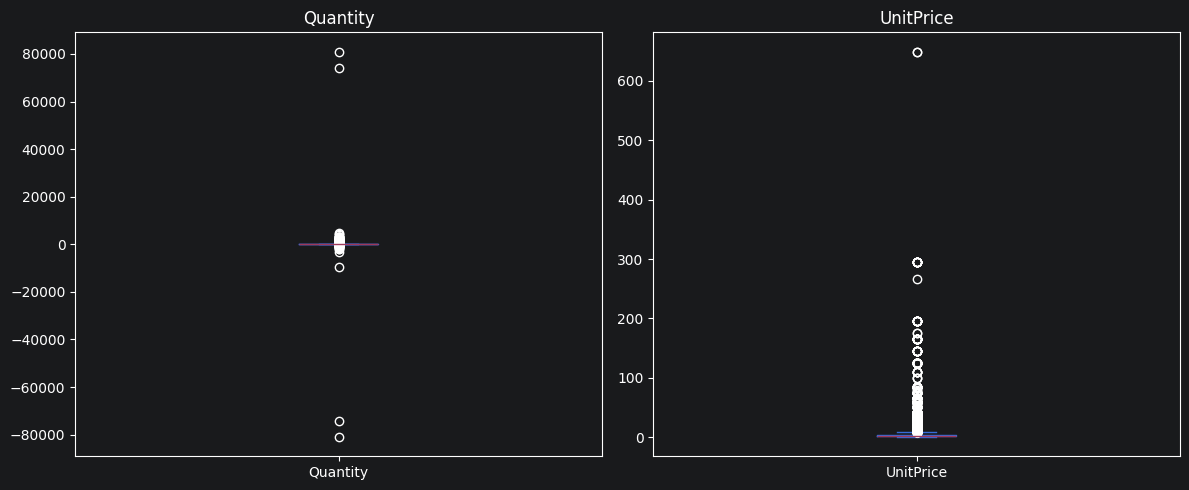

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

td["Quantity"].plot(kind="box", ax=axes[0], title="Quantity")
td["UnitPrice"].plot(kind="box", ax=axes[1], title="UnitPrice")

plt.tight_layout()
plt.show()

In [24]:
td[(td["Quantity"] > 60000) | (td["Quantity"] < -60000)]

,InvoiceNo,StockCode,Quantity,UnitPrice
61619,541431,23166,74215,1.04
61624,C541433,23166,-74215,1.04
540421,581483,23843,80995,2.08
540422,C581484,23843,-80995,2.08


In [25]:
# Find invoice numbers with quantities > 6000 and remove - looks like errors since differ that much from the rest + have corresponding returns
extreme = td[td["Quantity"].abs() > 60000]["InvoiceNo"].unique()
td = td[~td["InvoiceNo"].isin(extreme)]

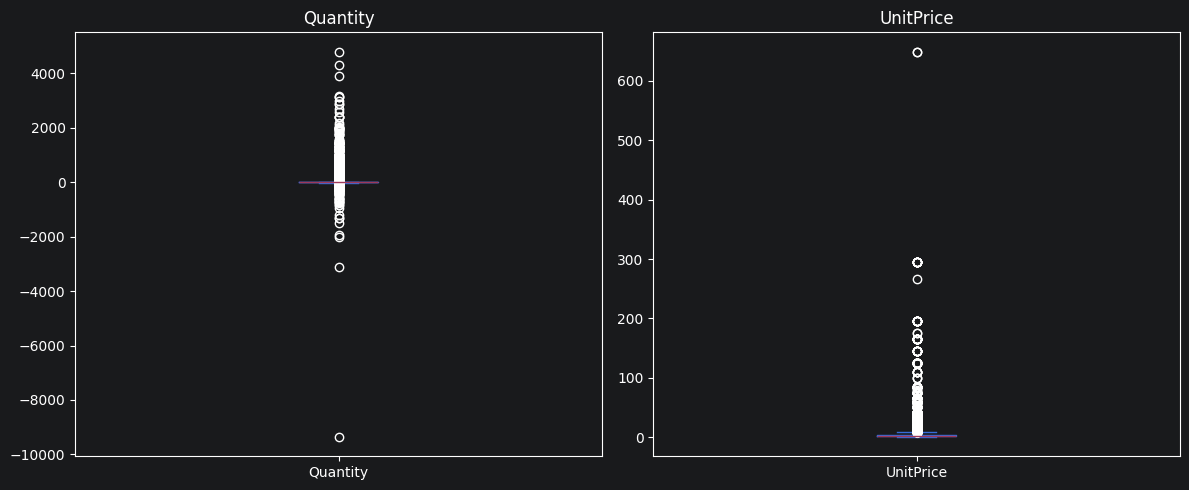

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

td["Quantity"].plot(kind="box", ax=axes[0], title="Quantity")
td["UnitPrice"].plot(kind="box", ax=axes[1], title="UnitPrice")

plt.tight_layout()
plt.show()

In [27]:
td[(td["Quantity"] > 5000) | (td["Quantity"] < -5000)] # Comment: no corresponding buy-return. Could be correct - keep

,InvoiceNo,StockCode,Quantity,UnitPrice
4287,C536757,84347,-9360,0.03


In [28]:
td[td["UnitPrice"] > 200]

,InvoiceNo,StockCode,Quantity,UnitPrice
4989,536835,22655,1,295.0
32484,539080,22655,1,295.0
36165,C539438,22655,-1,295.0
51636,540647,22655,1,295.0
51674,C540652,22655,-1,265.5
82768,543253,22655,1,295.0
87141,C543632,22655,-1,295.0
118769,546480,22656,1,295.0
133994,547814,22656,1,295.0
171178,551393,22656,1,295.0


In [29]:
# List products where deviations in price have been the biggest
td.groupby("StockCode")["UnitPrice"].agg(
    min=("min"),
    max=("max"),
    mean=("mean"),
    std=("std"),
    median=("median"),
    range=lambda x: x.max() - x.min()
).sort_values("std", ascending=False).head(20)

,min,max,mean,std,median,range
StockCode,,,,,,
22655,50.00,295.00,150.663043,67.163983,125.00,245.00
22656,50.00,295.00,143.653846,58.575724,125.00,245.00
22826,42.50,195.00,115.388889,50.800287,85.00,152.50
22502,2.00,649.50,10.215663,41.661999,5.95,647.50
22833,32.69,100.00,56.508000,25.435572,49.95,67.31
21769,52.77,79.95,66.360000,19.219162,66.36,27.18
21473,19.95,99.96,23.760000,17.459613,19.95,80.01
23064,10.00,99.96,43.921515,17.397149,49.95,89.96
22827,85.00,165.00,156.034483,16.549671,165.00,80.00


In [30]:
# Show how many transactions have a specific price for StockCode X
td[td["StockCode"] == 22502]["UnitPrice"].value_counts()

UnitPrice
5.95      216
10.79      98
8.29       96
4.95       32
8.47       29
649.50      2
8.95        1
2.00        1
Name: count, dtype: int64

In [31]:
td[td["InvoiceNo"].isin([556444, 556446])]

,InvoiceNo,StockCode,Quantity,UnitPrice
222680,556444,22502,60,649.5
222682,556446,22502,1,649.5


In [32]:
# Removes 2 outliers with price 649.5 - seems like error considering the normal price range for that product
td = td[~td["InvoiceNo"].isin([556444, 556446])]

In [33]:
# Add InvoiceDate, CustomerID, Country and Description back to the dataset after cleaning
td = td.merge(id, on="InvoiceNo", how="left")       # adds InvoiceDate
td = td.merge(ic, on="InvoiceNo", how="left")       # adds CustomerID
td = td.merge(cus, on="CustomerID", how="left")     # adds Country
td = td.merge(prod, on="StockCode", how="left")     # adds Description

In [34]:
td.sample(10)

,InvoiceNo,StockCode,Quantity,UnitPrice,InvoiceDate,CustomerID,Country,Description
267635,560779,22385,5,4.13,2011-07-21 09:30:00,NaN,NaN,JUMBO BAG SPACEBOY DESIGN
422414,573585,22646,2,3.29,2011-10-31 14:41:00,NaN,NaN,CERAMIC STRAWBERRY CAKE MONEY BANK
416144,573264,23273,5,1.65,2011-10-28 12:36:00,14415.0,United Kingdom,HEART T-LIGHT HOLDER WILLIE WINKIE
11296,537254,47559B,2,1.25,2010-12-06 11:01:00,15898.0,United Kingdom,TEA TIME OVEN GLOVE
273708,561258,85049G,12,1.25,2011-07-26 12:03:00,15513.0,United Kingdom,CHOCOLATE BOX RIBBONS
189045,553496,21621,4,8.50,2011-05-17 12:47:00,14410.0,United Kingdom,VINTAGE UNION JACK BUNTING
375926,570008,22689,2,8.25,2011-10-07 09:30:00,13359.0,United Kingdom,DOORMAT MERRY CHRISTMAS RED
112707,546096,15044A,6,2.95,2011-03-09 11:59:00,15502.0,United Kingdom,PINK PAPER PARASOL
125071,547240,21985,1,0.29,2011-03-21 16:32:00,17585.0,United Kingdom,PACK OF 12 HEARTS DESIGN TISSUES
371256,569650,21791,72,1.06,2011-10-05 12:44:00,12415.0,Australia,VINTAGE HEADS AND TAILS CARD GAME


In [35]:
td.isna().sum() # Missing values for Customer ID (same as before) and for Country (since CustomerID is missing) but should not a problem for the second task

InvoiceNo           0
StockCode           0
Quantity            0
UnitPrice           0
InvoiceDate         0
CustomerID     131516
Country        131516
Description         0
dtype: int64

## Modeling


### Sales Performance Over Time

#### Q2. Examine the temporal distribution of the dataset. Is the company doing well? How does the number of sold items, revenue and the customer base change in time?
The company appears to be performing well, with all three metrics showing a positive trend from December 2010 to November 2011.


Number of sold items approximately doubled, increasing from around 350,000 to 700,000 units. <br>
Revenue grew from approximately £800,000 to £1,400,000, though it did not quite double. <br>
Unique customers per month grew from around 1,000 to 1,700. <br>


All three metrics show a particularly strong increase from August 2011 onwards.

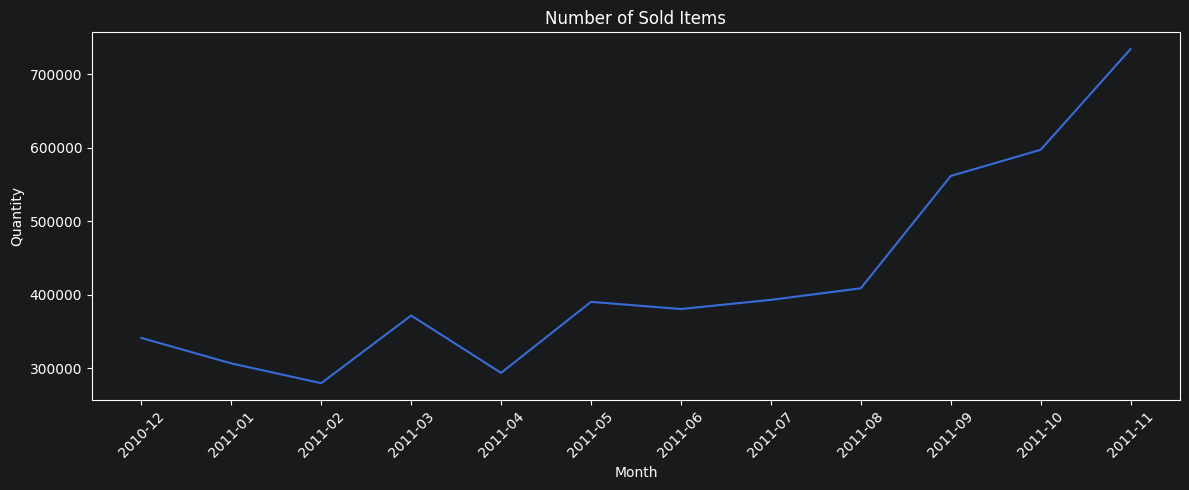

In [36]:
# Add a month column
td["Month"] = td["InvoiceDate"].dt.to_period("M")

# Aggregate quantity per month
items_per_month = td.groupby("Month")["Quantity"].sum()
items_per_month = items_per_month[items_per_month.index <= "2011-11"]  # Not complete data for Dec-11

# Plot
plt.figure(figsize=(12, 5))
plt.plot(items_per_month.index.astype(str), items_per_month.values)
plt.title("Number of Sold Items")       # including returns
plt.xlabel("Month")
plt.ylabel("Quantity")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

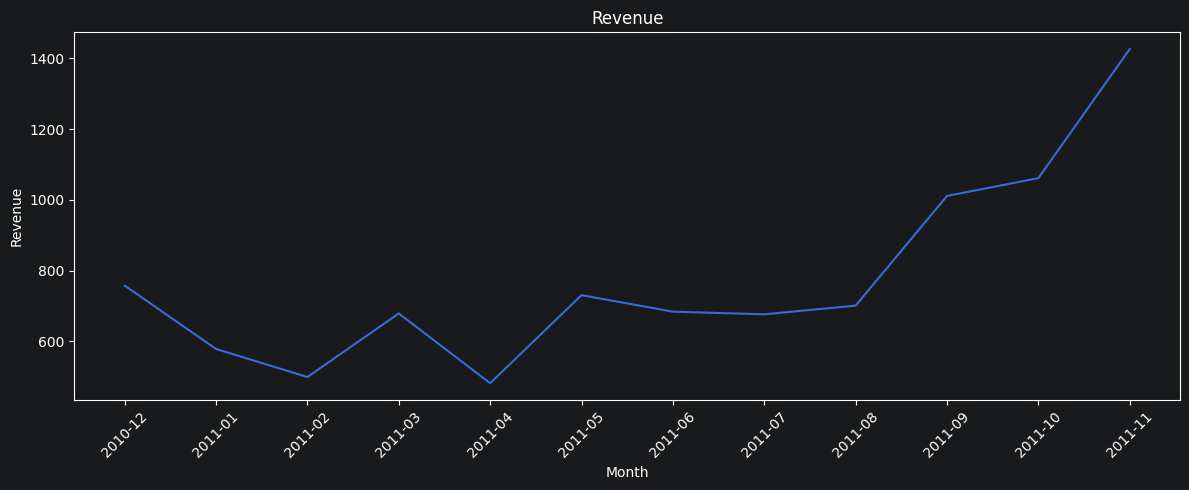

In [37]:
# Add revenue column
td["Revenue"] = td["Quantity"] * td["UnitPrice"]

# Aggregate revenue per month
revenue_per_month = td.groupby("Month")["Revenue"].sum() / 1000
revenue_per_month = revenue_per_month[revenue_per_month.index <= "2011-11"]

# Plot
plt.figure(figsize=(12, 5))
plt.plot(revenue_per_month.index.astype(str), revenue_per_month.values)
plt.title("Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

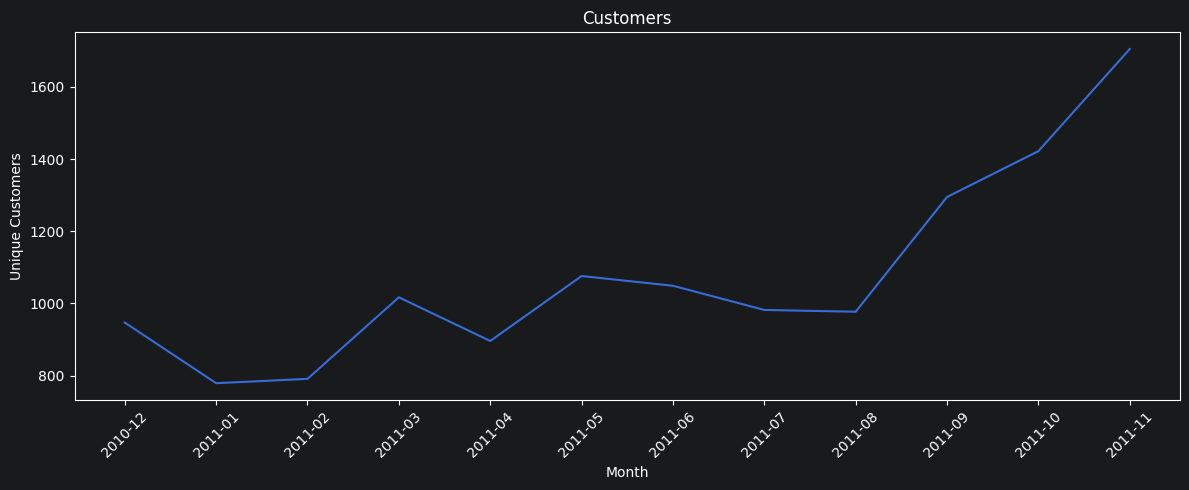

In [38]:
# Aggregate unique customers per month
customers_per_month = td.groupby("Month")["CustomerID"].nunique()

customers_per_month = customers_per_month[customers_per_month.index <= "2011-11"]

# Plot
plt.figure(figsize=(12, 5))
plt.plot(customers_per_month.index.astype(str), customers_per_month.values)
plt.title("Customers")
plt.xlabel("Month")
plt.ylabel("Unique Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Clustering

#### Q3. Can you identify groups of customers with common behavior? Specifically, with respect to the recency, frequency and amount of their purchases? How can you describe these customer groups?

##### Cluster 0 — Occasional Customers (47.4%)

- Purchased fairly recently (median 44 days ago)
- Buy infrequently (median 2 orders)
- Spend moderate amounts (median £504)
- The largest group — typical average customers

##### Cluster 1 — Lost/Inactive Customers (22.7%)

- Haven't purchased in a long time (median 247 days ago)
- Buy very rarely (median 1 order)
- Spend little (median £269)
- At risk of being permanently lost

##### Cluster 2 — Loyal High Spenders (29.9%)

- Purchased very recently (median 16 days ago)
- Buy frequently (median 7 orders)
- Spend a lot (median £2 491)
- Most valuable group despite being only 30% of the base

##### Further characteristics across all clusters:
- Unit price: all three clusters buy items at similar price points, so price is not what sets them apart. Cluster 1 actually has the highest median price (£2.10), meaning they buy fewer items rather than cheaper ones.
- Quantity: Cluster 2 buys by far the most items (median 1486), compared to Cluster 0 (median 288) and Cluster 1 (median 134), which matches their higher spending.
- Geography: all clusters are mostly UK-based (around 90%), with small shares from Germany and France. Cluster 2 has slightly more international customers than the others.

In [39]:
# Copy of data for clustering
cld = td.copy()

# Remove rows with missing CustomerID
cld = cld[cld["CustomerID"].notna()]

# Removes customers whose total revenue is negative. Does not mean that all returns are removed - total amount they have spent (deducting returns) is more relevant than only orders
negative_customers = cld.groupby("CustomerID")["Revenue"].sum()
negative_customers = negative_customers[negative_customers < 0].index
cld = cld[~cld["CustomerID"].isin(negative_customers)]

print(cld.shape)



(399500, 10)


In [40]:
# Reference date for counting how many days since last buy(/return) - last date in the data + 1d
reference_date = cld["InvoiceDate"].max() + pd.Timedelta(days=1)

# Aggregate to only one row per customer. New df
rfa = cld.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (reference_date - x.max()).days),
    Frequency=("InvoiceNo", lambda x: x[~x.astype(str).str.startswith("C")].nunique()), # Remove returns for frequency
    Amount=("Revenue", "sum")
).reset_index()

print(rfa.shape)
print(rfa.head())

(4331, 4)
   CustomerID  Recency  Frequency   Amount
0     12347.0        2          7  4310.00
1     12348.0       75          4  1437.24
2     12349.0       19          1  1457.55
3     12350.0      310          1   294.40
4     12352.0       36          7  1265.41


In [41]:
rfa.isnull().sum()

CustomerID    0
Recency       0
Frequency     0
Amount        0
dtype: int64

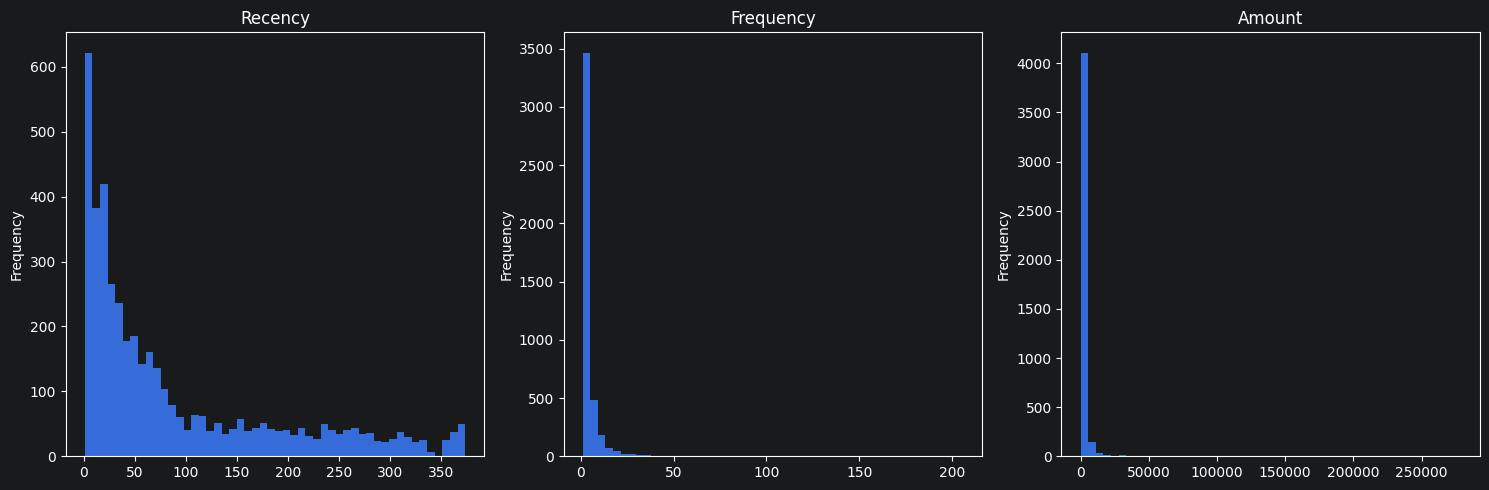

In [42]:
# To check if the data is normally distributed
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

rfa["Recency"].plot(kind="hist", bins=50, ax=axes[0], title="Recency")
rfa["Frequency"].plot(kind="hist", bins=50, ax=axes[1], title="Frequency")
rfa["Amount"].plot(kind="hist", bins=50, ax=axes[2], title="Amount")

plt.tight_layout()
plt.show()

In [43]:
rfa.describe()

,CustomerID,Recency,Frequency,Amount
count,4331.000000,4331.000000,4331.000000,4331.000000
mean,15299.126530,90.742554,4.247287,1900.129778
std,1721.562388,99.390835,7.637457,8273.541940
min,12347.000000,1.000000,1.000000,0.000000
25%,13812.500000,17.000000,1.000000,297.035000
50%,15297.000000,50.000000,2.000000,646.920000
75%,16778.500000,139.500000,5.000000,1599.820000
max,18287.000000,374.000000,206.000000,278778.020000


In [44]:
# Normalize Amount and Frequency because of heavily scewed data. Attempted log transformation on recency also but didnt improve much
# Log1 chosen because of 0 values in Amount
rfa["Amount_log"] = np.log1p(rfa["Amount"])
rfa["Frequency_log"] = np.log1p(rfa["Frequency"])
#

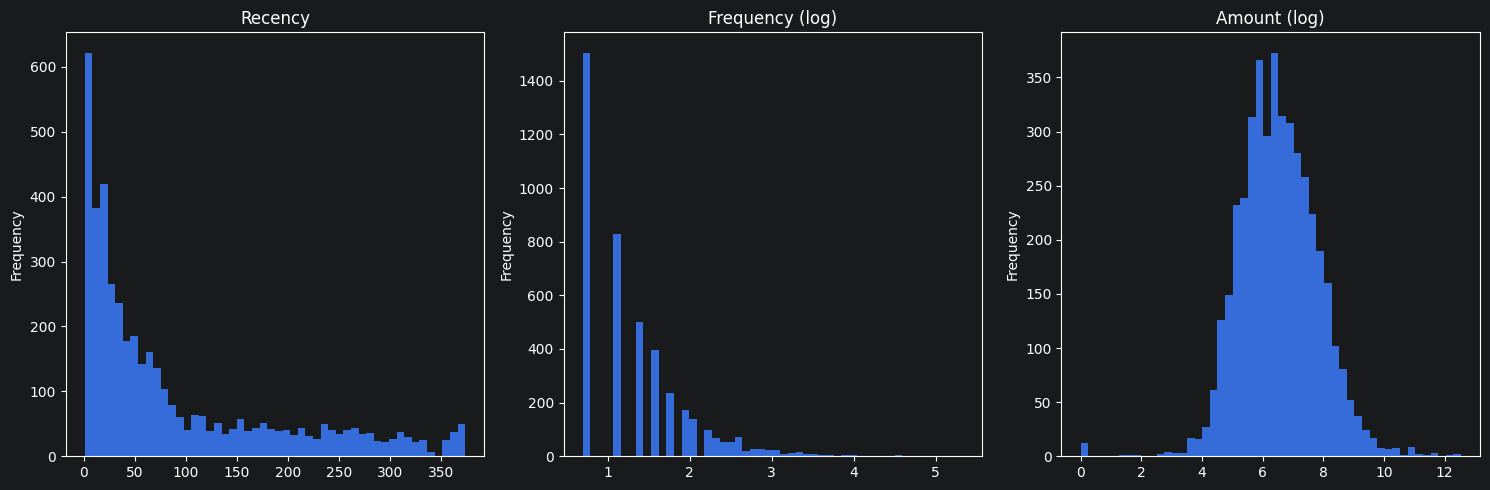

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

rfa["Recency"].plot(kind="hist", bins=50, ax=axes[0], title="Recency")
rfa["Frequency_log"].plot(kind="hist", bins=50, ax=axes[1], title="Frequency (log)")
rfa["Amount_log"].plot(kind="hist", bins=50, ax=axes[2], title="Amount (log)")

plt.tight_layout()
plt.show()

In [46]:
# Standardize the data with Z-score
scaler = StandardScaler()
rfa[["Recency_scaled", "Frequency_scaled", "Amount_scaled"]] = scaler.fit_transform(rfa[["Recency", "Frequency_log", "Amount_log"]])

In [47]:
rfa.describe()

,CustomerID,Recency,Frequency,Amount,Amount_log,Frequency_log,Recency_scaled,Frequency_scaled,Amount_scaled
count,4331.000000,4331.000000,4331.000000,4331.000000,4331.000000,4331.000000,4.331000e+03,4.331000e+03,4.331000e+03
mean,15299.126530,90.742554,4.247287,1900.129778,6.536303,1.341741,4.019464e-17,9.761555e-17,-2.132777e-16
std,1721.562388,99.390835,7.637457,8273.541940,1.293138,0.681999,1.000115e+00,1.000115e+00,1.000115e+00
min,12347.000000,1.000000,1.000000,0.000000,0.000000,0.693147,-9.030301e-01,-9.511290e-01,-5.055190e+00
25%,13812.500000,17.000000,1.000000,297.035000,5.697211,0.693147,-7.420309e-01,-9.511290e-01,-6.489555e-01
50%,15297.000000,50.000000,2.000000,646.920000,6.473767,1.098612,-4.099700e-01,-3.565355e-01,-4.836524e-02
75%,16778.500000,139.500000,5.000000,1599.820000,7.378270,1.791759,4.906194e-01,6.599287e-01,6.511794e-01
max,18287.000000,374.000000,206.000000,278778.020000,12.538175,5.332719,2.850264e+00,5.852561e+00,4.641860e+00


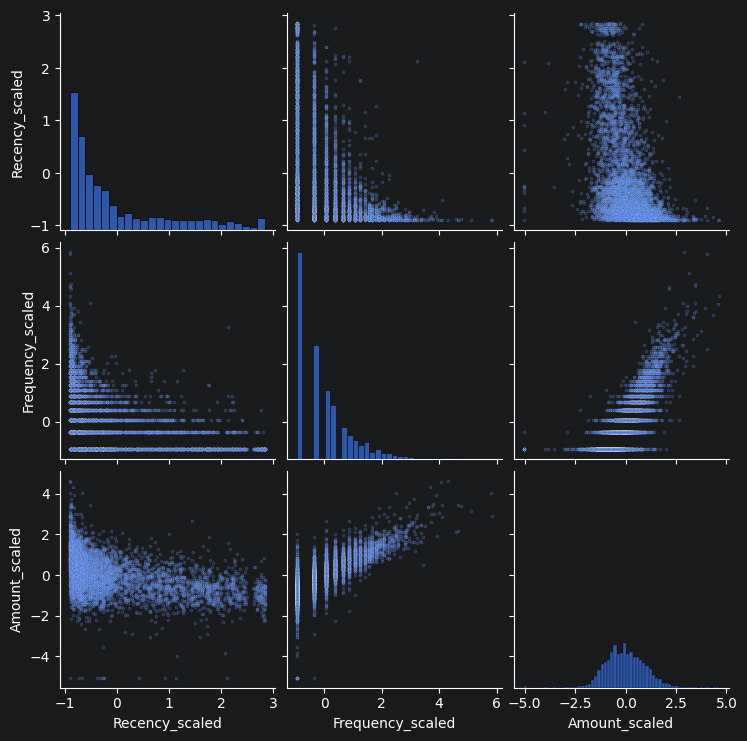

In [48]:
sns.pairplot(rfa[["Recency_scaled", "Frequency_scaled", "Amount_scaled"]],
             plot_kws={"alpha": 0.3, "s": 5})
plt.show()
# Looks a bit strange

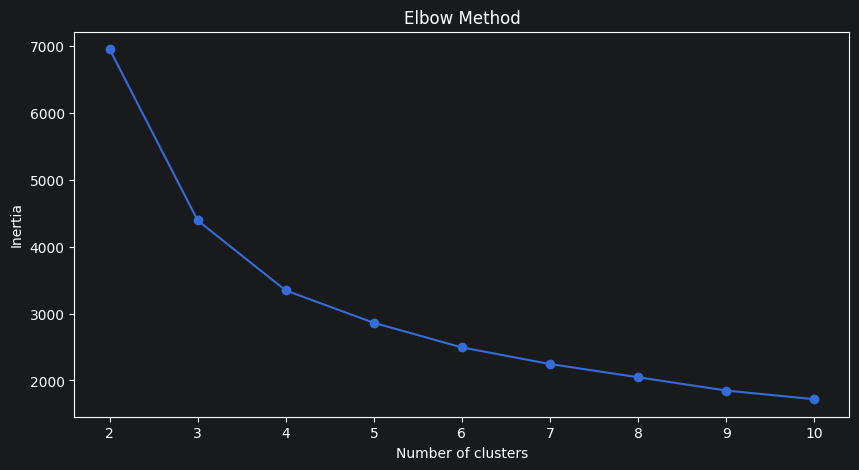

In [49]:
# Finding which k to use using the elbow method. Using Euclidean distance (default)
inertia = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfa[["Recency_scaled", "Frequency_scaled", "Amount_scaled"]])
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(k_range, inertia, marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.xticks(k_range)
plt.show()

In [50]:
# k=3 or k=4 looks like best choice. Use silhouette coefficient to decide
for k in [3, 4]:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfa[["Recency_scaled", "Frequency_scaled", "Amount_scaled"]])
    score = silhouette_score(rfa[["Recency_scaled", "Frequency_scaled", "Amount_scaled"]], labels)
    print(f"k={k}, silhouette score: {score:.3f}")

k=3, silhouette score: 0.414
k=4, silhouette score: 0.377


In [51]:
# Choose k = 3 due to higher silhouette. Silhouette 0.3 to 0.5 → reasonable clusters, some overlap
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# Runs K-means on scaled RFM data and assigns each customer a cluster (saved in new column)
rfa["Cluster"] = kmeans.fit_predict(rfa[["Recency_scaled", "Frequency_scaled", "Amount_scaled"]])

In [52]:
# Adds cluster labels to td
td = td.merge(rfa[["CustomerID", "Cluster"]], on="CustomerID", how="left") # merge the cluster labels back into td

In [53]:
rfa.head(10)

,CustomerID,Recency,Frequency,Amount,Amount_log,Frequency_log,Recency_scaled,Frequency_scaled,Amount_scaled,Cluster
0,12347.0,2,7,4310.00,8.368925,2.079442,-0.892968,1.081799,1.417354,2
1,12348.0,75,4,1437.24,7.271175,1.609438,-0.158409,0.392564,0.568352,2
2,12349.0,19,1,1457.55,7.285198,0.693147,-0.721906,-0.951129,0.579197,0
3,12350.0,310,1,294.40,5.688330,0.693147,2.206267,-0.951129,-0.655824,1
4,12352.0,36,7,1265.41,7.143941,2.079442,-0.550844,1.081799,0.469949,2
5,12353.0,204,1,89.00,4.499810,0.693147,1.139648,-0.951129,-1.575028,1
6,12354.0,232,1,1079.40,6.985087,0.693147,1.421396,-0.951129,0.347090,1
7,12355.0,214,1,459.40,6.132096,0.693147,1.240272,-0.951129,-0.312615,1
8,12356.0,23,3,2487.43,7.819407,1.386294,-0.681656,0.065335,0.992355,2
9,12357.0,33,1,6207.67,8.733702,0.693147,-0.581032,-0.951129,1.699473,0


Considered DBSCAN also but chose K-means because wanted to assign every customer to a cluster.

In [54]:
# Shows stats for each cluster
total_customers = len(rfa)
result = rfa.groupby("Cluster").agg(
    Count=("CustomerID", "count"),
    Recency_mean=("Recency", "mean"),
    Frequency_mean=("Frequency", "mean"),
    Amount_mean=("Amount", "mean"),
    Recency_median=("Recency", "median"),
    Frequency_median=("Frequency", "median"),
    Amount_median=("Amount", "median")
).round(2)

result["Pct_of_customers"] = (result["Count"] / total_customers * 100).round(1)

result

,Count,Recency_mean,Frequency_mean,Amount_mean,Recency_median,Frequency_median,Amount_median,Pct_of_customers
Cluster,,,,,,,,
0,2052,53.18,2.05,614.22,44.0,2.0,504.35,47.4
1,985,251.31,1.38,372.59,247.0,1.0,269.09,22.7
2,1294,28.08,9.91,5102.08,16.0,7.0,2490.94,29.9


In [55]:
# Mean and median price for items bought per cluster
td.groupby("Cluster")["UnitPrice"].agg(["mean", "median"]).round(2)

,mean,median
Cluster,,
0.0,2.83,1.69
1.0,3.39,2.10
2.0,2.89,1.95


In [56]:
# Mean and median number of items bought per cluster
td.groupby(["Cluster", "CustomerID"])["Quantity"].sum().reset_index().groupby("Cluster")["Quantity"].agg(["mean", "median"]).round(2)

,mean,median
Cluster,,
0.0,393.10,288.0
1.0,213.49,134.0
2.0,2981.88,1486.0


In [57]:
# Shows the top 5 countries per cluster with count and percentage of customers within that cluster
country_cluster = td.groupby(["Cluster", "Country"])["CustomerID"].nunique().reset_index()
country_cluster["Pct"] = country_cluster.groupby("Cluster")["CustomerID"].transform(lambda x: (x / x.sum() * 100).round(1))
country_cluster.sort_values(["Cluster", "CustomerID"], ascending=[True, False]).groupby("Cluster").head(10)

,Cluster,Country,CustomerID,Pct
27,0.0,United Kingdom,1852,90.3
11,0.0,Germany,46,2.2
10,0.0,France,39,1.9
22,0.0,Spain,15,0.7
24,0.0,Switzerland,10,0.5
20,0.0,Portugal,9,0.4
2,0.0,Belgium,8,0.4
9,0.0,Finland,7,0.3
14,0.0,Italy,7,0.3
7,0.0,Denmark,6,0.3


#### Q4. What kind of items do these customer groups commonly buy?


The most popular products are largely the same across all three clusters. Items like WHITE HANGING HEART T-LIGHT HOLDER, REGENCY CAKESTAND 3 TIER, PARTY BUNTING and ASSORTED COLOUR BIRD ORNAMENT appear in the top 10 for all clusters.


Some differences between the clusters:

- Cluster 2 (Loyal High Spenders) has more bag-related items in their top 10, such as JUMBO BAG RED RETROSPOT, LUNCH BAG RED RETROSPOT and JUMBO BAG VINTAGE DOILY
- Cluster 1 (Lost/Inactive Customers) has some unique items in their top 10 that don't appear for other clusters, like JAM MAKING SET WITH JARS and NATURAL SLATE HEART CHALKBOARD
- Cluster 0 (Occasional Customers) has similar products as Cluster 2 but with lower percentages



In [58]:
# Only rows with a known cluster
clt = td[td["Cluster"].notna()]

# How many unique invoices per cluster
invoices_per_cluster = clt.groupby("Cluster")["InvoiceNo"].nunique()

# How many invoices per cluster contain each item
item_cluster = (
    clt.groupby(["Cluster", "Description"])["InvoiceNo"]
    .nunique()
    .reset_index()
    .rename(columns={"InvoiceNo": "InvoiceCount"})
)

item_cluster["TotalInvoices"] = item_cluster["Cluster"].map(invoices_per_cluster)
item_cluster["Pct"] = (item_cluster["InvoiceCount"] / item_cluster["TotalInvoices"] * 100).round(2)

# Top 10 per cluster by percentage
item_cluster.sort_values(["Cluster", "Pct"], ascending=[True, False]).groupby("Cluster").head(10)


,Cluster,Description,InvoiceCount,TotalInvoices,Pct
3136,0.0,WHITE HANGING HEART T-LIGHT HOLDER,421,4854,8.67
2325,0.0,REGENCY CAKESTAND 3 TIER,393,4854,8.10
185,0.0,ASSORTED COLOUR BIRD ORNAMENT,349,4854,7.19
1951,0.0,PAPER CHAIN KIT 50'S CHRISTMAS,300,4854,6.18
2370,0.0,REX CASH+CARRY JUMBO SHOPPER,298,4854,6.14
234,0.0,BAKING SET 9 PIECE RETROSPOT,284,4854,5.85
2528,0.0,SET OF 3 CAKE TINS PANTRY DESIGN,266,4854,5.48
1977,0.0,PARTY BUNTING,262,4854,5.40
1480,0.0,JUMBO BAG RED RETROSPOT,246,4854,5.07
1348,0.0,HEART OF WICKER SMALL,227,4854,4.68


### MBA

#### Q5. What kind of items are typically bought together?

Different colors/designs of the same product
- Regency Teacups — Pink, Green and Roses versions bought together (has highest lift ~18)
- Charlotte Bags — different designs like Pink Polkadot, Red Retrospot and Suki bought together
- Jumbo Bags — Red Retrospot bought together with many other designs of the same bag
- Alarm Clocks — Green, Red and Pink Bakelike

Complementary products

- Gardeners Kneeling Pads in different designs bought together
- Heart of Wicker Large and Small bought together
- Regency Cakestand bought together with Regency Teacups


In [59]:
# For MBA
# New df where returns are removed
basket_data = td[~td["InvoiceNo"].astype(str).str.startswith("C") & (td["Quantity"] > 0)] # also removes any remaining negative quantities

# Groups by invoiceno and description and sums quantity + pivots it, fills empty cells with 0
basket = (basket_data
            .groupby(["InvoiceNo", "Description"])["Quantity"]
            .sum()
            .unstack()
            .fillna(0))
basket = basket > 0 # Converts all values to True or False

In [60]:
print(basket.shape)
basket.head()

(19769, 3774)


Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,TRELLIS COAT RACK,...,ZINC HERB GARDEN CONTAINER,ZINC METAL HEART DECORATION,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
InvoiceNo,,,,,,,,,,,,,,,,,,,,,
536365,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
536366,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
536367,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
536368,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
536369,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [61]:
# Uses Apriori algorithm. Support 0.02 - avoid generating too many and irrelevant itemsets
frequent_itemsets = apriori(basket, min_support=0.02, use_colnames=True)
print(f"Frequent itemsets found: {len(frequent_itemsets)}")

Frequent itemsets found: 395


In [62]:
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5)  # 0.5 confidence as limit - how likely is to occur
rules.sort_values(["lift", "support", "confidence"], ascending=False)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
49,"frozenset({GREEN REGENCY TEACUP AND SAUCER, RO...",frozenset({PINK REGENCY TEACUP AND SAUCER}),0.038798,0.038697,0.027366,0.705346,18.227419,1.0,0.025865,3.262475,0.983287,0.545913,0.693484,0.706268
54,frozenset({PINK REGENCY TEACUP AND SAUCER}),"frozenset({GREEN REGENCY TEACUP AND SAUCER, RO...",0.038697,0.038798,0.027366,0.707190,18.227419,1.0,0.025865,3.282676,0.983184,0.545913,0.695370,0.706268
51,"frozenset({ROSES REGENCY TEACUP AND SAUCER , P...",frozenset({GREEN REGENCY TEACUP AND SAUCER}),0.030249,0.051242,0.027366,0.904682,17.655147,1.0,0.025816,9.953638,0.972785,0.505607,0.899534,0.719370
52,frozenset({GREEN REGENCY TEACUP AND SAUCER}),"frozenset({ROSES REGENCY TEACUP AND SAUCER , P...",0.051242,0.030249,0.027366,0.534057,17.655147,1.0,0.025816,2.081266,0.994310,0.505607,0.519523,0.719370
17,frozenset({PINK REGENCY TEACUP AND SAUCER}),frozenset({GREEN REGENCY TEACUP AND SAUCER}),0.038697,0.051242,0.031969,0.826144,16.122445,1.0,0.029986,5.457143,0.975733,0.551483,0.816754,0.725017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31,frozenset({JUMBO SHOPPER VINTAGE RED PAISLEY}),frozenset({JUMBO BAG RED RETROSPOT}),0.059436,0.105670,0.034397,0.578723,5.476679,1.0,0.028117,2.122903,0.869062,0.263158,0.528947,0.452119
57,"frozenset({GREEN REGENCY TEACUP AND SAUCER, RO...",frozenset({REGENCY CAKESTAND 3 TIER}),0.038798,0.100561,0.020638,0.531943,5.289725,1.0,0.016737,1.921642,0.843688,0.173839,0.479612,0.368587
24,frozenset({JUMBO BAG APPLES}),frozenset({JUMBO BAG RED RETROSPOT}),0.049471,0.105670,0.027619,0.558282,5.283236,1.0,0.022391,2.024663,0.852917,0.216581,0.506091,0.409826
34,frozenset({RECYCLING BAG RETROSPOT }),frozenset({JUMBO BAG RED RETROSPOT}),0.037837,0.105670,0.020992,0.554813,5.250404,1.0,0.016994,2.008884,0.841374,0.171346,0.502211,0.376736
